# 08 · Geliştirilmiş model (v2)

İlk modelin (v1) eksikleri belliydi: `other_vehicle` öğrenilmemişti, `bicycle` zayıftı ve mAP eğrileri 20. epoch'ta hâlâ yükseliyordu. İkinci eğitimde **daha çok veri ve daha uzun süre** denendi.

| | v1 | **v2** |
|---|---|---|
| Eğitim / doğrulama | 3.000 / 600 | **10.000 / 2.000** |
| Epoch | 20 | **40** |
| Model | yolo11n | yolo11n (aynı) |
| Süre (Tesla T4) | 20 dk | 2,6 saat |
| **mAP50** | 0.789 | **0.857** |
| **mAP50-95** | 0.554 | **0.642** |
| Precision | 0.879 | 0.863 |
| Recall | 0.719 | **0.816** |

Model boyutu bilerek sabit tutuldu: fark yalnızca **veri miktarı ve eğitim süresinden** gelsin diye.

## 1. Sınıf bazlı değişim

| Sınıf | v1 | v2 | Değişim |
|---|---|---|---|
| mine | 0.991 | 0.995 | ~ |
| gun | 0.978 | 0.977 | ~ |
| drone | 0.938 | **0.980** | ↑ |
| person | 0.930 | **0.967** | ↑ |
| car | 0.926 | **0.959** | ↑ |
| **bicycle** | 0.627 | **0.798** | ↑↑ |
| **other_vehicle** | 0.133 | **0.323** | ↑↑ |

En çok iyileşenler, v1'de en zayıf olan iki sınıf. Teşhis doğruydu: sorun bu sınıflardan **yeterli örnek görülmemesiydi**. 3.000 yerine 10.000 fotoğrafta `other_vehicle`'dan 6 yerine 16, `bicycle`'dan 52 yerine 310 örnek var.

## 2. Hazırlık: iki modeli birden yükle

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from collections import Counter                       # tahminleri sınıfa göre saymak için

v1 = YOLO("../models/iha_yolo11n.pt")                 # 3.000 fotoğraf / 20 epoch
v2 = YOLO("../models/iha_yolo11n_v2.pt")              # 10.000 fotoğraf / 40 epoch

def oku(ad, bolum="train"):                           # fotoğrafı + etiket kutularını döndürür
    foto = cv2.imread(f"../data/kucuk_paket/images/{bolum}/{ad}.png")
    yukseklik, genislik = foto.shape[0], foto.shape[1]

    kutular = []
    with open(f"../data/kucuk_paket/labels/{bolum}/{ad}.txt") as dosya:
        etiketler = dosya.read().splitlines()

    for satir in etiketler:
        parcalar = satir.split()
        numara = int(parcalar[0])
        mx = float(parcalar[1]) * genislik
        my = float(parcalar[2]) * yukseklik
        g  = float(parcalar[3]) * genislik
        y  = float(parcalar[4]) * yukseklik
        kutular.append((numara,
                        round(mx - g/2), round(my - y/2),
                        round(mx + g/2), round(my + y/2)))

    return foto, kutular

print("v1 sınıfları:", v1.names)
print("v2 sınıfları:", v2.names)

v1 sınıfları: {0: 'person', 1: 'car', 2: 'bicycle', 3: 'other_vehicle', 4: 'drone', 5: 'mine', 6: 'gun'}
v2 sınıfları: {0: 'person', 1: 'car', 2: 'bicycle', 3: 'other_vehicle', 4: 'drone', 5: 'mine', 6: 'gun'}


## 3. Aynı fotoğraflarda iki model
Her fotoğrafı iki modele de verip buldukları kutuları sınıfa göre sayıyoruz.

In [2]:
def karsilastir(ad, gercek_aciklama, bolum="train"):
    foto, _ = oku(ad, bolum)
    print(f"{ad}   (gerçek: {gercek_aciklama})")

    fig, eksenler = plt.subplots(1, 2, figsize=(16, 7))

    for eksen, model, isim in [(eksenler[0], v1, "v1 — 3.000 foto / 20 epoch"),
                               (eksenler[1], v2, "v2 — 10.000 foto / 40 epoch")]:
        sonuc = model(foto, verbose=False)[0]
        sayim = Counter(model.names[int(kutu.cls)] for kutu in sonuc.boxes)   # sınıf sayımı
        print(f"   {isim:32} {len(sonuc.boxes):3} kutu   {dict(sayim)}")

        eksen.imshow(cv2.cvtColor(sonuc.plot(), cv2.COLOR_BGR2RGB))
        eksen.set_title(isim)
        eksen.axis("off")

    plt.tight_layout()
    plt.show()

### 3.1 Kuşbakışı termal otopark
Gerçekte 20 `car` + 1 `other_vehicle` var. Sol alttaki büyük araç (kamyonet) `other_vehicle` olarak etiketli.

02_hituav__0_100_50_0_08164__c5427da128   (gerçek: 20 car + 1 other_vehicle)


   v1 — 3.000 foto / 20 epoch        23 kutu   {'car': 23}
   v2 — 10.000 foto / 40 epoch       22 kutu   {'car': 21, 'other_vehicle': 1}


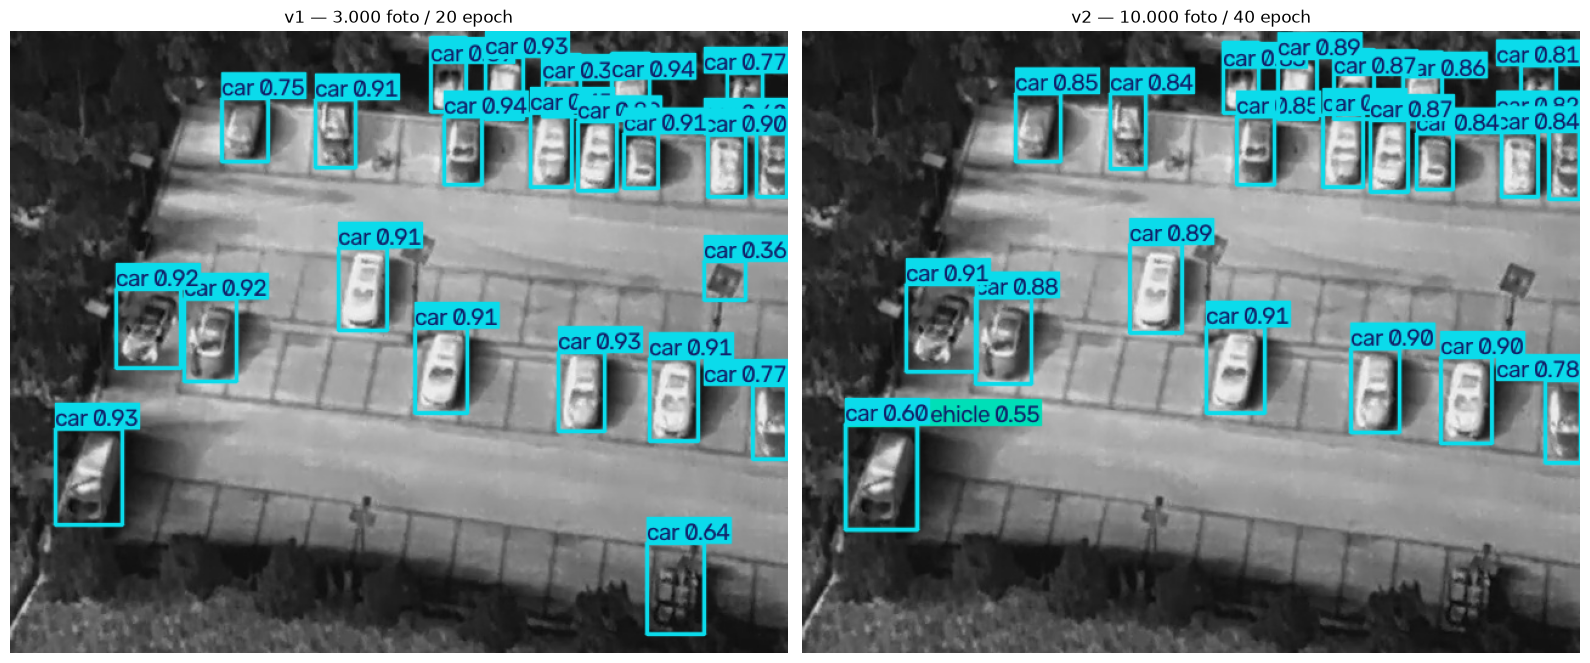

In [3]:
karsilastir("02_hituav__0_100_50_0_08164__c5427da128", "20 car + 1 other_vehicle")

**Sonuç:** v1 → 23 kutu, **hepsi `car`**. v2 → 22 kutu, **21 `car` + 1 `other_vehicle`**.

v2 kamyoneti doğru sınıflandırdı. `other_vehicle` mAP50'sinin 0.133 → 0.323 çıkmasının somut karşılığı bu.

### 3.2 Sokak seviyesinden termal görüntü

03_llvip__120019__91781a1c2d   (gerçek: 3 car + 5 person)
   v1 — 3.000 foto / 20 epoch         9 kutu   {'car': 4, 'person': 5}


   v2 — 10.000 foto / 40 epoch        9 kutu   {'car': 4, 'person': 5}


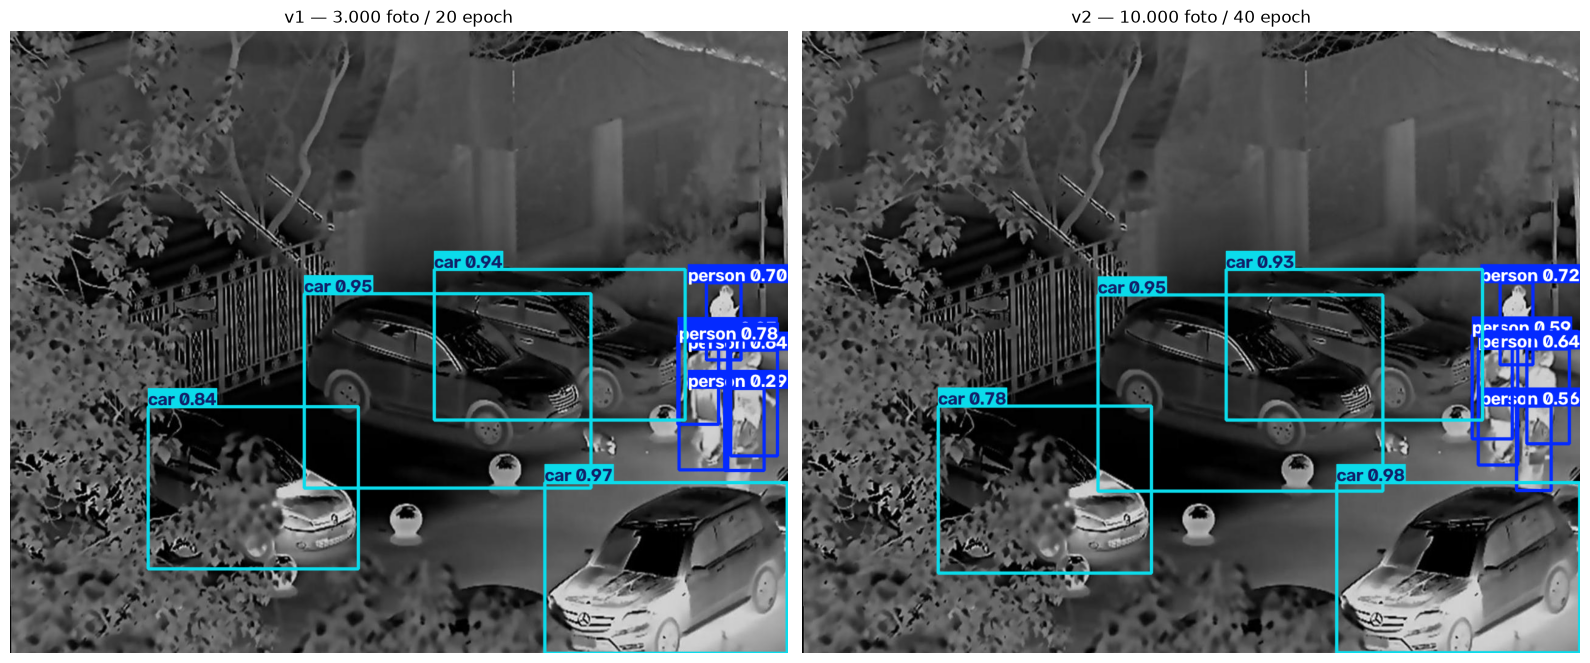

In [4]:
karsilastir("03_llvip__120019__91781a1c2d", "3 car + 5 person")

### 3.3 Gökyüzünde İHA

01_uav2uav__430__864a7aebf1   (gerçek: 2 drone)
   v1 — 3.000 foto / 20 epoch         2 kutu   {'drone': 2}
   v2 — 10.000 foto / 40 epoch        2 kutu   {'drone': 2}


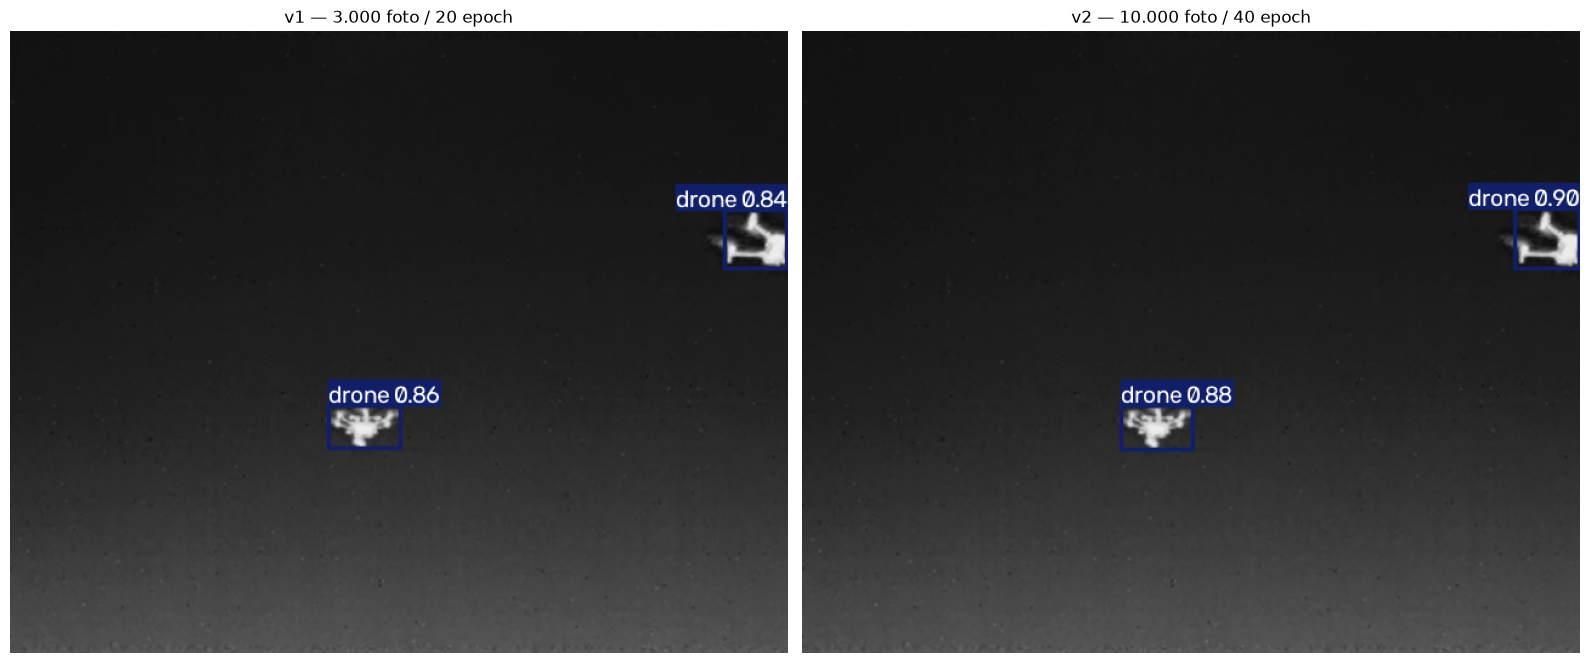

In [5]:
karsilastir("01_uav2uav__430__864a7aebf1", "2 drone")

## 4. Kestirme öğrenme düzeldi mi?

06'da bulduğumuz sorun: model İHA'yı yalnızca düz koyu arka planda tanıyor. Daha çok veriyle eğitilen v2 bunu aşmış mı?

Aynı deney: İHA parçası kesilip iki farklı arka plana yapıştırılıyor, iki modele de soruluyor.

In [6]:
iha, kutular = oku("01_uav2uav__430__864a7aebf1")
numara, x1, y1, x2, y2 = kutular[0]
parca = iha[y1:y2, x1:x2].copy()                       # İHA'yı kes
ph, pw = parca.shape[0], parca.shape[1]

otopark, _ = oku("02_hituav__0_100_50_0_08164__c5427da128")
asfalt = otopark.copy()
asfalt[400:400+ph, 300:300+pw] = parca                 # asfalta yapıştır

duz = np.full((512, 640, 3), 30, np.uint8)             # her pikseli 30 olan düz koyu tuval
duz[240:240+ph, 290:290+pw] = parca                    # aynı parçayı oraya da yapıştır

def drone_var_mi(model, resim, bolge, conf=0.05):      # conf düşük: zayıf tahminleri de görelim
    sonuc = model(resim, verbose=False, conf=conf)[0]
    bx1, by1, bx2, by2 = bolge
    bulunan = []
    for kutu in sonuc.boxes:
        kx1, ky1, kx2, ky2 = kutu.xyxy[0].tolist()
        if kx1 < bx2 + 20 and kx2 > bx1 - 20 and ky1 < by2 + 20 and ky2 > by1 - 20:
            bulunan.append((model.names[int(kutu.cls)], round(float(kutu.conf), 2)))
    return bulunan if bulunan else "HİÇBİR ŞEY"

for isim, model in [("v1", v1), ("v2", v2)]:
    print(isim, "| asfalt        ->", drone_var_mi(model, asfalt, (300, 400, 300+pw, 400+ph)))
    print(isim, "| düz koyu tuval->", drone_var_mi(model, duz,    (290, 240, 290+pw, 240+ph)))

v1 | asfalt        -> HİÇBİR ŞEY
v1 | düz koyu tuval-> [('drone', 0.91)]
v2 | asfalt        -> HİÇBİR ŞEY
v2 | düz koyu tuval-> [('drone', 0.88)]


**Sonuç: düzelmemiş.**

| Model | Asfalt | Düz koyu tuval |
|---|---|---|
| v1 | ❌ | ✅ drone 0.91 |
| **v2** | ❌ | ✅ drone 0.88 |

Üç kat veri ve iki kat epoch sorunu çözmedi. Sebebi mantıklı: eklenen 7.000 fotoğrafta da bütün İHA'lar gökyüzündeydi. Model daha çok örnek gördü ama **hep aynı türden**; "gökyüzü = İHA" kuralı tekrar tekrar pekişti.

**Ders: veri miktarı her sorunu çözmez.** Az örnekli sınıflar (`other_vehicle`, `bicycle`) miktardan fayda gördü; kestirme öğrenme ise **çeşitlilik** sorunu olduğu için görmedi.

## 5. Eğitim grafikleri (v2)

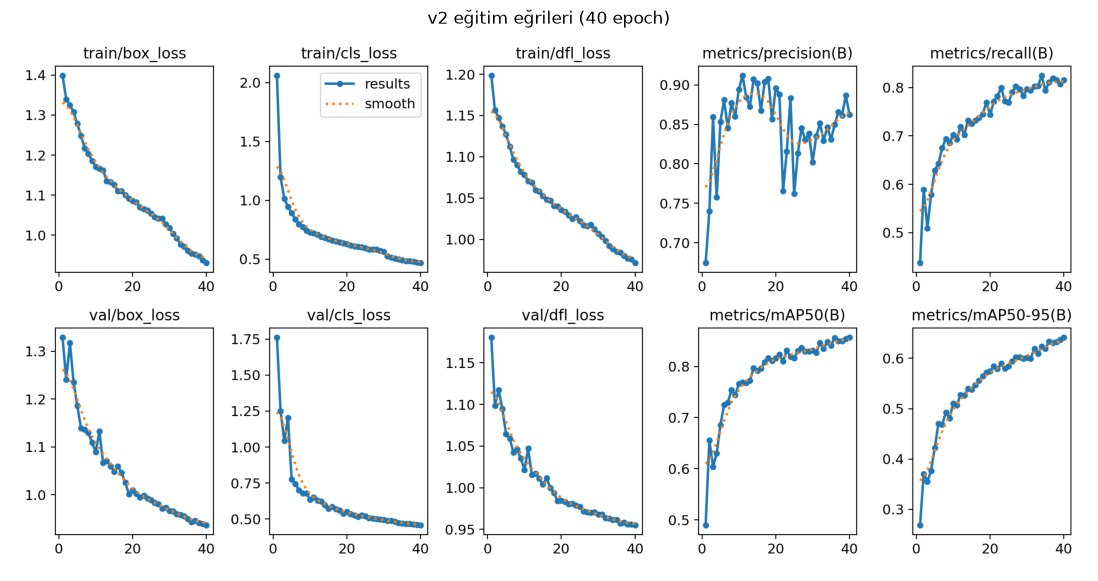

In [7]:
def grafik_goster(dosya, baslik, boyut=(15, 7)):
    resim = plt.imread("../egitim_sonuclari/v2/" + dosya)
    plt.figure(figsize=boyut)
    plt.imshow(resim)
    plt.title(baslik)
    plt.axis("off")
    plt.show()

grafik_goster("results.png", "v2 eğitim eğrileri (40 epoch)")

**Okunanlar:**
- Train ve val kayıpları birlikte düşüyor → ezberleme yok
- mAP50 0.49 → 0.857, mAP50-95 0.27 → 0.642
- Eğriler sona doğru **yatıklaşmış**. v1'de dimdik yükseliyordu; artık doygunluğa yaklaşıyor. Aynı kurulumla daha uzun eğitmek büyük kazanç getirmez, bundan sonrası **veri çeşitliliği** ya da **daha büyük model** ile gelir.
- Precision eğrisi dalgalı: model her epoch'ta "az kutu çiz / çok kutu çiz" dengesini yeniden ayarlıyor. Recall'ın düzenli yükselmesi ise kaçırmanın sürekli azaldığını gösteriyor.

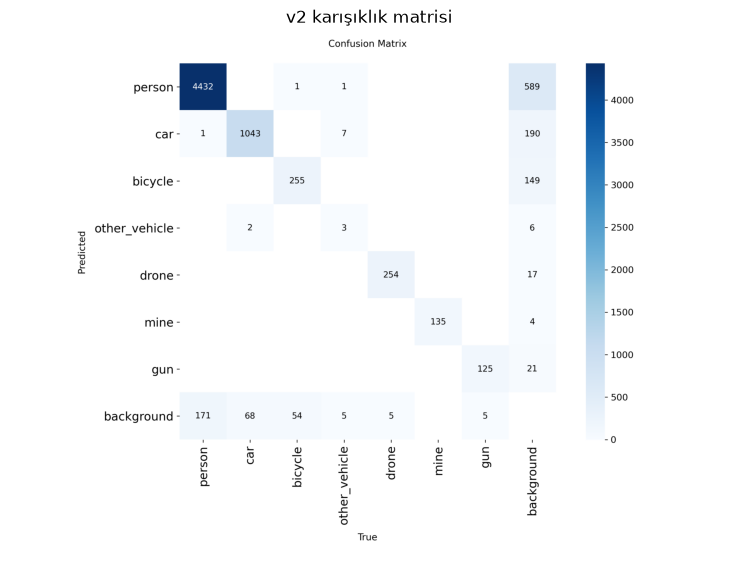

In [8]:
grafik_goster("confusion_matrix.png", "v2 karışıklık matrisi")

**Okunanlar:**
- Köşegen dolu: person 4432, car 1043, bicycle 255, drone 254, mine 135, gun 125 doğru
- **`other_vehicle` satırı artık boş değil:** 3 doğru tahmin var. v1'de model bu sınıfı hiç kullanmıyordu.
- Sınıflar arası karışıklık hâlâ çok az; `other_vehicle` ile `car` arasında birkaç karışma var, beklenen bir durum (kamyonet arabaya benziyor).
- Hatalar yine ağırlıklı olarak son satır ve sütunda: **yanlış alarm** (589 person) ve **kaçırma** (171 person).

## Sonuç

**İyileşen:** Genel başarı (mAP50 0.789 → 0.857), özellikle az örnekli sınıflar. v2 artık kamyoneti `other_vehicle` olarak tanıyor.

**İyileşmeyen:** Kestirme öğrenme. Model hâlâ İHA'yı yalnızca düz koyu arka planda tanıyor.

### Sıradaki adım: copy-paste augmentation

Sorun veri çeşitliliği olduğuna göre çözüm de orada:

1. İHA parçalarını kesip **farklı arka planlara** (otopark, sokak, yol) yapıştırarak yapay eğitim fotoğrafları üretmek
2. Yapıştırılan yerin koordinatı bilindiği için **etiketlerini de kendimiz yazmak**
3. Bunları eğitim setine ekleyip yeniden eğitmek
4. Aynı testi tekrarlamak: İHA artık asfaltta tanınıyor mu?

Bu yöntem literatürde biliniyor ve gereken bütün adımları (kesme, yapıştırma, etiket yazma) bu projede zaten öğrendik.